# Machine Learning Modeling 

## Import Libraries

In [1]:
# import general python packages 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

# import classfier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# import model selection and preprocessing tools 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, f1_score


## Import Data 

In [2]:
X_train = pd.read_csv("data/X_train.csv", sep=",", low_memory= False) 
X_test = pd.read_csv("data/X_test.csv", sep=",", low_memory=False)

y_train = pd.read_csv("data/y_train.csv", sep=",", low_memory=False) 
y_test = pd.read_csv("data/y_test.csv", sep=",", low_memory=False) 

group_train = pd.read_csv("data/group_train.csv").iloc[:, 0]
group_test = pd.read_csv("data/group_test.csv").iloc[:, 0]

# Check lengths 
print(f"X: {len(X_train)}, y: {len(y_train)}, groups: {len(group_train)}")

X: 1524, y: 1524, groups: 1524


## Define the Datasets

- **Dataset 1:** Full feature set. Remove rows with missing values in Polyphen_Score and SIFT_Score.
- **Dataset 2:** Exlude the features 'Polyphen_Score','SIFT_Score' 'missing_Polyphen', 'missing_SIFT'. 
- **Dataset 3:** Exclude the feature 'Consequence'. Remove missing values in 'Polyphen_Score' and 'SIFT_Score'.
- **Dataset 4:** Exclude the features 'Polyphen_Score', 'SIFT_Score', 'missing_Polyphen', 'missing_SIFT', 'Consequence'.

## Create Datasets

### Define columns to handle

In [3]:
# Define columns to handle 
score_columns = ["Polyphen_Score", "SIFT_Score"] 
missing_columns = ["missing_Polyphen", "missing_SIFT"] 
consequence_column = ["Consequence"]

### Check column names

In [4]:
# Check column names
print(X_train.columns.tolist())

['Consequence', 'Variant_Type', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'missing_Polyphen', 'missing_SIFT', 'gnomAD_AF_log']


### Dataset 1

In [5]:
# Dataset 1: Full feature set, remove rows with missing values 
mask_train = X_train[score_columns].notna().all(axis=1) 
mask_test = X_test[score_columns].notna().all(axis=1) 

X_train_1 = X_train[mask_train].copy()
y_train_1 = y_train[mask_train].copy()
X_test_1 = X_test[mask_test].copy()
y_test_1 = y_test[mask_test].copy()

group_train_1 = group_train[mask_train]

# control that no rows has missing values 
print(f"X_train_1 has {(X_train_1.isna().sum().sum())} missing values.") 

X_train_1 has 0 missing values.


In [6]:
print("The five first rows of X_train_1:")  
display(X_train_1.head())

The five first rows of X_train_1:


,Consequence,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,gnomAD_AF_log
0,missense_variant,SNP,False,0.908,0.00,False,False,0,False,0,0,0,-6.000000
1,missense_variant,SNP,True,0.007,0.08,False,True,1,False,0,0,0,-5.301436
2,missense_variant,SNP,False,0.087,0.31,False,False,0,False,0,0,0,-6.000000
3,missense_variant,SNP,False,0.497,0.01,False,True,1,True,1,0,0,-6.000000
4,missense_variant,SNP,True,0.586,0.01,False,False,0,True,1,0,0,-5.047830


### Dataset 2

In [7]:
# Dataset 2: Exlude the features 'Polyphen_Score','SIFT_Score' 'missing_Polyphen', 'missing_SIFT'. 
cols_to_drop_2 = score_columns + missing_columns 
X_train_2 = X_train.drop(columns=cols_to_drop_2)
X_test_2 = X_test.drop(columns=cols_to_drop_2)
y_train_2 = y_train.copy()
y_test_2 = y_test.copy()

group_train_2 = group_train.copy() 

# Check column names in the new dataset 
print(X_train_2.columns.tolist())

# control that no rows has missing values 
print(f"X_train_2 has {(X_train_2.isna().sum().sum())} missing values.")

['Consequence', 'Variant_Type', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'gnomAD_AF_log']
X_train_2 has 0 missing values.


In [8]:
print("The five first rows of X_train_2:")  
display(X_train_2.head())

The five first rows of X_train_2:


,Consequence,Variant_Type,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,gnomAD_AF_log
0,missense_variant,SNP,False,False,False,0,False,0,-6.000000
1,missense_variant,SNP,True,False,True,1,False,0,-5.301436
2,missense_variant,SNP,False,False,False,0,False,0,-6.000000
3,missense_variant,SNP,False,False,True,1,True,1,-6.000000
4,missense_variant,SNP,True,False,False,0,True,1,-5.047830


### Dataset 3 

In [9]:
# Dataset 3: exclude the column 'Consequence', remove missing values in Polyphen and SIFT. 
mask_train = X_train[score_columns].notna().all(axis=1)
mask_test = X_test[score_columns].notna().all(axis=1)

X_train_3 = X_train[mask_train].drop(columns=consequence_column)
X_test_3 = X_test[mask_test].drop(columns=consequence_column)
y_train_3 = y_train[mask_train].copy()
y_test_3 = y_test[mask_test].copy()

group_train_3 = group_train[mask_train]

# control column names
print(X_train_3.columns.tolist())

# control that no rows has missing values 
print(f"X_train_3 has {(X_train_3.isna().sum().sum())} missing values.")

['Variant_Type', 'has_gnomAD_AF', 'Polyphen_Score', 'SIFT_Score', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'missing_Polyphen', 'missing_SIFT', 'gnomAD_AF_log']
X_train_3 has 0 missing values.


In [10]:
print("The five first rows of X_train_3:")  
display(X_train_3.head())

The five first rows of X_train_3:


,Variant_Type,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,missing_Polyphen,missing_SIFT,gnomAD_AF_log
0,SNP,False,0.908,0.00,False,False,0,False,0,0,0,-6.000000
1,SNP,True,0.007,0.08,False,True,1,False,0,0,0,-5.301436
2,SNP,False,0.087,0.31,False,False,0,False,0,0,0,-6.000000
3,SNP,False,0.497,0.01,False,True,1,True,1,0,0,-6.000000
4,SNP,True,0.586,0.01,False,False,0,True,1,0,0,-5.047830


### Dataset 4 

In [11]:
cols_to_drop_4 = score_columns + missing_columns + consequence_column

X_train_4 = X_train.drop(columns=cols_to_drop_4)
X_test_4 = X_test.drop(columns=cols_to_drop_4)
y_train_4 = y_train.copy()
y_test_4 = y_test.copy()

group_train_4 = group_train.copy() 

# control column names
print(X_train_4.columns.tolist())

# control that no rows has missing values 
print(f"X_train_4 has {(X_train_4.isna().sum().sum())} missing values.")  

['Variant_Type', 'has_gnomAD_AF', 'In_Hotspot', 'IN_DOMAIN', 'n_protein_domains', 'IN_FUNC_SITE', 'n_func_sites', 'gnomAD_AF_log']
X_train_4 has 0 missing values.


In [12]:
print("The five first rows of X_train_4:")  
display(X_train_4.head())

The five first rows of X_train_4:


,Variant_Type,has_gnomAD_AF,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,gnomAD_AF_log
0,SNP,False,False,False,0,False,0,-6.000000
1,SNP,True,False,True,1,False,0,-5.301436
2,SNP,False,False,False,0,False,0,-6.000000
3,SNP,False,False,True,1,True,1,-6.000000
4,SNP,True,False,False,0,True,1,-5.047830


## Define the Pipelines

In [13]:
categorical_feat = ["Variant_Type", "has_gnomAD_AF", "Consequence", "In_Hotspot", "IN_DOMAIN", "IN_FUNC_SITE"]

def create_pipeline(df, model, categorical_feat): 
  """
  Creates ML-pipeline based on categorical columns in df, 
  for the chosen ML classifier. 
  """
  existing_cat = [c for c in categorical_feat if c in df.columns]
  existing_num = df.columns.difference(existing_cat).tolist() 

  preprocessor = ColumnTransformer(
        transformers=[
            ('num', RobustScaler(), existing_num),
            ('cat', OneHotEncoder(handle_unknown='ignore'), existing_cat)
        ])
  
  return Pipeline([
    ('preprocessor', preprocessor),
    ('clf', model)
  ])

In [14]:
# Define the logistic regression pipeline
pipe_logistic1 = create_pipeline(X_train_1, LogisticRegression(max_iter=1000), categorical_feat)
pipe_logistic2 = create_pipeline(X_train_2, LogisticRegression(max_iter=1000), categorical_feat)
pipe_logistic3 = create_pipeline(X_train_3, LogisticRegression(max_iter=1000), categorical_feat)
pipe_logistic4 = create_pipeline(X_train_4, LogisticRegression(max_iter=1000), categorical_feat)

# Define the random forest pipeline
pipe_rf1 = create_pipeline(X_train_1, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf2 = create_pipeline(X_train_2, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf3 = create_pipeline(X_train_3, RandomForestClassifier(random_state=1), categorical_feat) 
pipe_rf4 = create_pipeline(X_train_4, RandomForestClassifier(random_state=1), categorical_feat) 

# Define the xgboost pipeline 
pipe_xgb1 = create_pipeline(X_train_1, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb2 = create_pipeline(X_train_2, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb3 = create_pipeline(X_train_3, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)
pipe_xgb4 = create_pipeline(X_train_4, XGBClassifier(random_state=1, tree_method='hist'), categorical_feat)

## **ML Modeling**

## Linear Regression Model

### Define CV-strategy and hyperparameters to test 

In [15]:
cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42) 

gs_logistic1 = GridSearchCV(
  estimator=pipe_logistic1, 
  param_grid={'clf__C': [0.1,1,10]},
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

gs_logistic2 = GridSearchCV(
  estimator=pipe_logistic2, 
  param_grid={'clf__C': [0.1,1,10]},
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

gs_logistic3 = GridSearchCV(
  estimator=pipe_logistic3, 
  param_grid={'clf__C': [0.1,1,10]},
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

gs_logistic4 = GridSearchCV(
  estimator=pipe_logistic4, 
  param_grid={'clf__C': [0.1,1,10]},
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

### Fit logistic model to all training data 

In [16]:
gs_logistic_1 = gs_logistic1.fit(X_train_1, y_train_1.values.ravel(), groups=group_train_1)

print(f"The best F1-score (Macro) for dataset 1: {gs_logistic_1.best_score_}")
print(f"The best hyperparameters: {gs_logistic_1.best_params_}")

gs_logistic_2 = gs_logistic2.fit(X_train_2, y_train_2.values.ravel(), groups=group_train_2)

print(f"The best F1-score (Macro) for dataset 2: {gs_logistic_2.best_score_}")
print(f"The best hyperparameters: {gs_logistic_2.best_params_}")

gs_logistic_3 = gs_logistic3.fit(X_train_3, y_train_3.values.ravel(), groups=group_train_3)

print(f"The best F1-score (Macro) for dataset 3: {gs_logistic_3.best_score_}")
print(f"The best hyperparameters: {gs_logistic_3.best_params_}")

gs_logistic_4 = gs_logistic4.fit(X_train_4, y_train_4.values.ravel(), groups=group_train_4)

print(f"The best F1-score (Macro) for dataset 4: {gs_logistic_4.best_score_}")
print(f"The best hyperparameters: {gs_logistic_4.best_params_}")

The best F1-score (Macro) for dataset 1: 0.6980412725861584
The best hyperparameters: {'clf__C': 1}
The best F1-score (Macro) for dataset 2: 0.7108825035824695
The best hyperparameters: {'clf__C': 0.1}
The best F1-score (Macro) for dataset 3: 0.6994101959585104
The best hyperparameters: {'clf__C': 1}
The best F1-score (Macro) for dataset 4: 0.7110678804014684
The best hyperparameters: {'clf__C': 0.1}


### Evaluate model performance

Dataset 1

In [17]:
# Predict classes for dataset 1 
y_pred_1 = gs_logistic_1.predict(X_test_1)

# Predict probabilities
y_probs_1 = gs_logistic_1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

Test F1-score (Macro): 0.7135

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       162
           1       0.78      0.58      0.67       150

    accuracy                           0.72       312
   macro avg       0.74      0.72      0.71       312
weighted avg       0.73      0.72      0.72       312



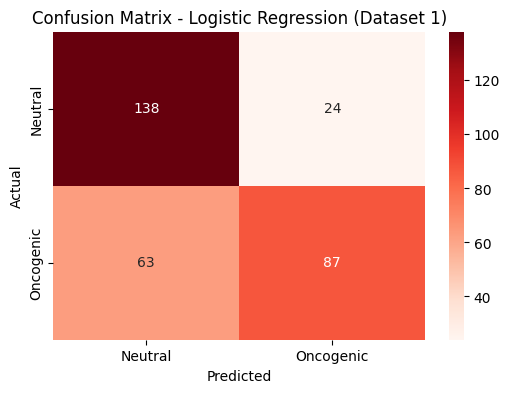

In [18]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 1)')
plt.show()

In [ ]:
# Predict classes for dataset 2
y_pred_2 = gs_logistic_2.predict(X_test_2)

# Predict probabilities
y_probs_2 = gs_logistic_2.predict_proba(X_test_2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_2, y_pred_2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_2))

Test F1-score (Macro): 0.7319

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.88      0.75       172
           1       0.86      0.61      0.72       210

    accuracy                           0.73       382
   macro avg       0.76      0.75      0.73       382
weighted avg       0.77      0.73      0.73       382



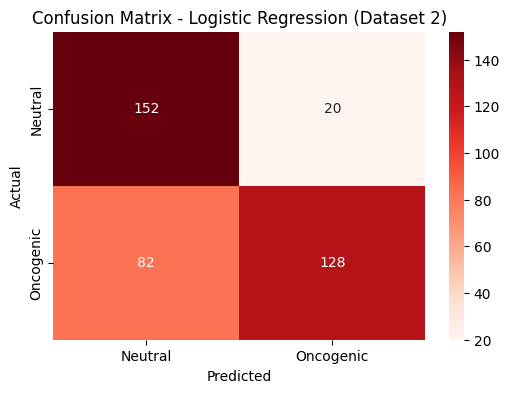

In [20]:
cm = confusion_matrix(y_test_2, y_pred_2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 2)')
plt.show()

In [ ]:
# Predict classes for dataset 3
y_pred_3 = gs_logistic_3.predict(X_test_3)

# Predict probabilities
y_probs_3 = gs_logistic_3.predict_proba(X_test_3)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_3, y_pred_3, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_3, y_pred_3))

Test F1-score (Macro): 0.7135

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76       162
           1       0.78      0.58      0.67       150

    accuracy                           0.72       312
   macro avg       0.74      0.72      0.71       312
weighted avg       0.73      0.72      0.72       312



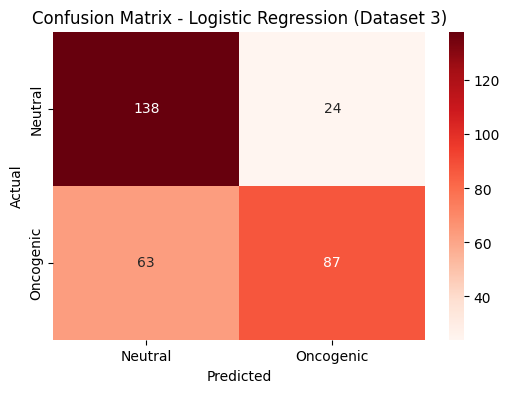

In [22]:
cm = confusion_matrix(y_test_3, y_pred_3)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 3)')
plt.show()

In [ ]:
# Predict classes for dataset 4
y_pred_4 = gs_logistic_4.predict(X_test_4)

# Predict probabilities
y_probs_4 = gs_logistic_4.predict_proba(X_test_4)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_4, y_pred_4, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_4, y_pred_4))

Test F1-score (Macro): 0.7345

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.89      0.75       172
           1       0.87      0.61      0.72       210

    accuracy                           0.74       382
   macro avg       0.76      0.75      0.73       382
weighted avg       0.77      0.74      0.73       382



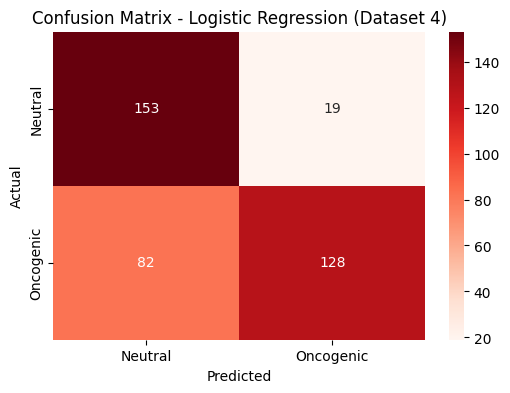

In [24]:
cm = confusion_matrix(y_test_4, y_pred_4)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 4)')
plt.show()

## Random Forest Model

### Define CV-strategy and hyperparameters to test 

In [25]:
cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42) 

gs_rf1 = GridSearchCV(
  estimator=pipe_rf1,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

gs_rf2 = GridSearchCV(
  estimator=pipe_rf2,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

gs_rf3 = GridSearchCV(
  estimator=pipe_rf3,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

gs_rf4 = GridSearchCV(
  estimator=pipe_rf4,
  param_grid={'clf__n_estimators': [225,250,275],
  'clf__max_features': ['sqrt'],
  'clf__max_depth': [10,15],
  'clf__criterion': ['entropy'],
  'clf__min_samples_split': [2, 4],
  'clf__min_samples_leaf': [1, 2]}, 
  scoring='f1_macro',
  cv=cv_strategy,
  n_jobs=-1)

### Fit random forest model to all training data 

In [ ]:
gs_rf1 = gs_rf1.fit(X_train_1, y_train_1.values.ravel(), groups=group_train_1) 

print(gs_rf1.best_score_)
print(gs_rf1.best_params_)

print(f"The best F1-score (Macro) for dataset 1: {gs_rf1.best_score_}")
print(f"The best hyperparameters: {gs_rf1.best_params_}")

gs_rf2 = gs_rf2.fit(X_train_2, y_train_2.values.ravel(), groups=group_train_2) 

print(gs_rf2.best_score_)
print(gs_rf2.best_params_)

print(f"The best F1-score (Macro) for dataset 2: {gs_rf2.best_score_}")
print(f"The best hyperparameters: {gs_rf2.best_params_}")

gs_rf3 = gs_rf3.fit(X_train_3, y_train_3.values.ravel(), groups=group_train_3) 

print(gs_rf3.best_score_)
print(gs_rf3.best_params_)

print(f"The best F1-score (Macro) for dataset 3: {gs_rf3.best_score_}")
print(f"The best hyperparameters: {gs_rf3.best_params_}")


gs_rf4 = gs_rf4.fit(X_train_4, y_train_4.values.ravel(), groups=group_train_4) 

print(gs_rf4.best_score_)
print(gs_rf4.best_params_)

print(f"The best F1-score (Macro) for dataset 4: {gs_rf4.best_score_}")
print(f"The best hyperparameters: {gs_rf4.best_params_}")

0.7303871674884771
{'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 250}
The best F1-score (Macro) for dataset 1: 0.7303871674884771
The best hyperparameters: {'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 250}
0.6765902412370105
{'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 4, 'clf__n_estimators': 275}
The best F1-score (Macro) for dataset 2: 0.6765902412370105
The best hyperparameters: {'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 4, 'clf__n_estimators': 275}
0.7331696276885052
{'clf__criterion': 'entropy', 'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__

### Evaluate model performance 

Dataset 1

In [ ]:
# Predict classes for dataset 1 
y_pred_1 = gs_rf1.predict(X_test_1)

# Predict probabilities
y_probs_1 = gs_rf1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

In [ ]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 1)')
plt.show()

Dataset 2

In [ ]:
# Predict classes for dataset 2
y_pred_2 = gs_rf2.predict(X_test_2)

# Predict probabilities
y_probs_2 = gs_rf2.predict_proba(X_test_2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_2, y_pred_2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_2))

In [ ]:
cm = confusion_matrix(y_test_2, y_pred_2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 2)')
plt.show()

Dataset 3

In [ ]:
# Predict classes for dataset 3 
y_pred_3 = gs_rf3.predict(X_test_3)

# Predict probabilities
y_probs_3 = gs_rf3.predict_proba(X_test_3)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_3, y_pred_3, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_3, y_pred_3))

In [ ]:
cm = confusion_matrix(y_test_3, y_pred_3)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Dataset 3)')
plt.show()

Dataset 4

In [ ]:
# Predict classes for dataset 4
y_pred_4 = gs_logistic_4.predict(X_test_4)

# Predict probabilities
y_probs_4 = gs_logistic_4.predict_proba(X_test_4)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_4, y_pred_4, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_4, y_pred_4))

In [ ]:
cm = confusion_matrix(y_test_4, y_pred_4)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Neutral', 'Oncogenic'], 
            yticklabels=['Neutral', 'Oncogenic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (Dataset 4)')
plt.show()

## XGBoost modeling

### Define CV-strategy and hyperparameters to test 

In [27]:
cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42) 

gs_xgb1 = GridSearchCV(pipe_xgb1, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.05, 0.1],
                        'clf__max_depth': [3, 5, 7],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1],
                        'clf__tree_method': ['hist']})

gs_xgb2 = GridSearchCV(pipe_xgb2, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.05, 0.1],
                        'clf__max_depth': [3, 5, 7],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1],
                        'clf__tree_method': ['hist']})

gs_xgb3 = GridSearchCV(pipe_xgb3, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.05, 0.1],
                        'clf__max_depth': [3, 5, 7],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1],
                        'clf__tree_method': ['hist']})

gs_xgb4 = GridSearchCV(pipe_xgb4, 
                      param_grid={
                        'clf__n_estimators': [100, 200],
                        'clf__learning_rate': [0.01, 0.05, 0.1],
                        'clf__max_depth': [3, 5, 7],
                        'clf__subsample': [0.8],
                        'clf__colsample_bytree': [0.8],
                        'clf__gamma': [0, 0.1],
                        'clf__tree_method': ['hist']})


In [28]:
gs_xgb_1 = gs_xgb2.fit(X_train_1, y_train_1.values.ravel(), groups=group_train_1) 

print(gs_xgb_1.best_score_)
print(gs_xgb_1.best_params_)

print(f"The best F1-score (Macro) for dataset 1: {gs_xgb_1.best_score_}")
print(f"The best hyperparameters: {gs_xgb_1.best_params_}")

gs_xgb_2 = gs_xgb2.fit(X_train_2, y_train_2.values.ravel(), groups=group_train_2) 

print(gs_xgb_2.best_score_)
print(gs_xgb_2.best_params_)

print(f"The best F1-score (Macro) for dataset 2: {gs_xgb_2.best_score_}")
print(f"The best hyperparameters: {gs_xgb_2.best_params_}")

gs_xgb_3 = gs_xgb3.fit(X_train_2, y_train_2.values.ravel(), groups=group_train_2) 

print(gs_xgb_2.best_score_)
print(gs_xgb_2.best_params_)

print(f"The best F1-score (Macro) for dataset 2: {gs_xgb_2.best_score_}")
print(f"The best hyperparameters: {gs_xgb_2.best_params_}")

gs_xgb_4 = gs_xgb4.fit(X_train_3, y_train_3.values.ravel(), groups=group_train_3) 

print(gs_xgb_3.best_score_)
print(gs_xgb_3.best_params_)

print(f"The best F1-score (Macro) for dataset 3: {gs_xgb_3.best_score_}")
print(f"The best hyperparameters: {gs_xgb_3.best_params_}")

/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


0.7170292887029288
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8, 'clf__tree_method': 'hist'}
The best F1-score (Macro) for dataset 1: 0.7170292887029288
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8, 'clf__tree_method': 'hist'}


/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


0.7270319240724763
{'clf__colsample_bytree': 0.8, 'clf__gamma': 0.1, 'clf__learning_rate': 0.01, 'clf__max_depth': 7, 'clf__n_estimators': 200, 'clf__subsample': 0.8, 'clf__tree_method': 'hist'}
The best F1-score (Macro) for dataset 2: 0.7270319240724763
The best hyperparameters: {'clf__colsample_bytree': 0.8, 'clf__gamma': 0.1, 'clf__learning_rate': 0.01, 'clf__max_depth': 7, 'clf__n_estimators': 200, 'clf__subsample': 0.8, 'clf__tree_method': 'hist'}


/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:885: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


ValueError: 
All the 180 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
180 fits failed with the following error:
Traceback (most recent call last):
  File "/home/anekl/git/master/machine_learning_pipeline/.venv/lib/python3.13/site-packages/pandas/core/indexes/base.py", line 3641, in get_loc
    return self._engine.get_loc(casted_key)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "pandas/_libs/index.pyx", line 168, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index.pyx", line 197, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7668, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7676, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'Poly

### Evaluate Model Performance

### Dataset 1

In [ ]:
# Predict classes for dataset 1 
y_pred_1 = gs_xgb_1.predict(X_test_1)

# Predict probabilities
y_probs_1 = gs_xgb_1.predict_proba(X_test_1)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_1, y_pred_1, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_1, y_pred_1))

Test F1-score (Macro): 0.7258

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       162
           1       0.74      0.67      0.70       150

    accuracy                           0.73       312
   macro avg       0.73      0.73      0.73       312
weighted avg       0.73      0.73      0.73       312



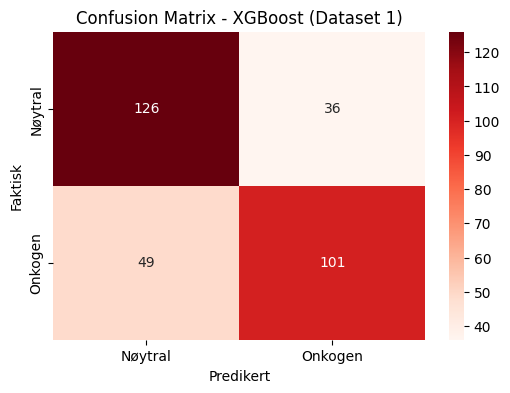

In [ ]:
cm = confusion_matrix(y_test_1, y_pred_1)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Nøytral', 'Onkogen'], 
            yticklabels=['Nøytral', 'Onkogen'])
plt.xlabel('Predikert')
plt.ylabel('Faktisk')
plt.title('Confusion Matrix - XGBoost (Dataset 1)')
plt.show()

### Dataset 2

In [ ]:
# Predict classes for dataset 2
y_pred_2 = gs_xgb_2.predict(X_test_2)

# Predict probabilities
y_probs_2 = gs_xgb_2.predict_proba(X_test_2)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_2, y_pred_2, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_2, y_pred_2))

Test F1-score (Macro): 0.7563

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.88      0.76       172
           1       0.87      0.66      0.75       210

    accuracy                           0.76       382
   macro avg       0.77      0.77      0.76       382
weighted avg       0.78      0.76      0.76       382



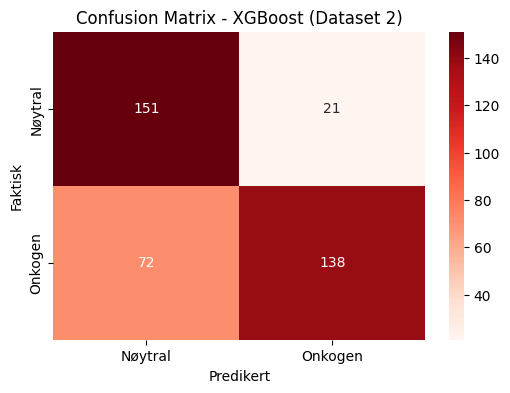

In [ ]:
cm = confusion_matrix(y_test_2, y_pred_2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Nøytral', 'Onkogen'], 
            yticklabels=['Nøytral', 'Onkogen'])
plt.xlabel('Predikert')
plt.ylabel('Faktisk')
plt.title('Confusion Matrix - XGBoost (Dataset 2)')
plt.show()

### Dataset 3

In [ ]:
# Predict classes for dataset 3 
y_pred_3 = gs_xgb_3.predict(X_test_3)

# Predict probabilities
y_probs_3 = gs_xgb_3.predict_proba(X_test_3)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_3, y_pred_3, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_3, y_pred_3))

Test F1-score (Macro): 0.7126

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       162
           1       0.73      0.65      0.69       150

    accuracy                           0.71       312
   macro avg       0.72      0.71      0.71       312
weighted avg       0.72      0.71      0.71       312



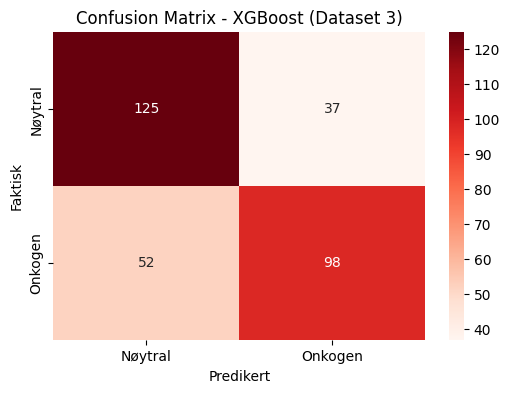

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_3, y_pred_3)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Nøytral', 'Onkogen'], 
            yticklabels=['Nøytral', 'Onkogen'])
plt.xlabel('Predikert')
plt.ylabel('Faktisk')
plt.title('Confusion Matrix - XGBoost (Dataset 3)')
plt.show()

### Dataset 4

In [ ]:
# Predict classes for dataset 4 
y_pred_4 = gs_xgb_4.predict(X_test_4)

# Predict probabilities
y_probs_4 = gs_xgb_4.predict_proba(X_test_4)[:, 1]

# F1-score 
test_f1 = f1_score(y_test_4, y_pred_4, average='macro')
print(f"Test F1-score (Macro): {test_f1:.4f}")

# Classification report 
print("\nClassification Report:")
print(classification_report(y_test_4, y_pred_4))

Test F1-score (Macro): 0.7247

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.76      0.71       172
           1       0.78      0.70      0.74       210

    accuracy                           0.73       382
   macro avg       0.73      0.73      0.72       382
weighted avg       0.73      0.73      0.73       382



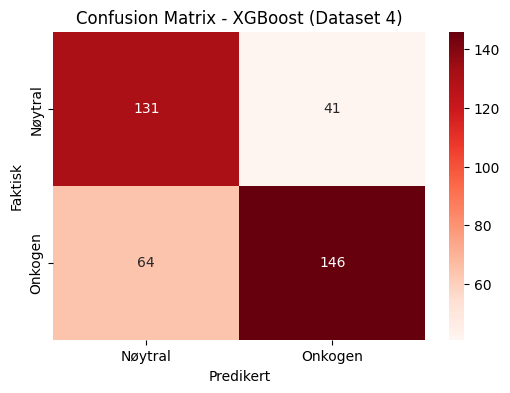

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_4, y_pred_4)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Nøytral', 'Onkogen'], 
            yticklabels=['Nøytral', 'Onkogen'])
plt.xlabel('Predikert')
plt.ylabel('Faktisk')
plt.title('Confusion Matrix - XGBoost (Dataset 4)')
plt.show()